In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("daraz_sales.csv")
df.head()

,Order_ID,Customer_Name,Customer_City,Product_Name,Category,Price,Quantity,Order_Date,Delivery_Date,Payment_Method,Order_Status,Seller_Name
0,O00001,Nicole Walsh PhD,South Melissa,Pro Headphones,Electronics,1513.75,4,2024-03-24,2024-03-28,Online Banking,Pending,Turner Group
1,O00002,Vanessa Berry,Garciastad,Super Smartwatch,Books,903.48,1,2024-12-14,2024-12-24,Debit Card,Returned,Medina-Rivers
2,O00003,Christina Kramer,Fergusonborough,Innovative Headphones,Books,582.08,3,2024-12-19,2024-12-20,Cash On Delivery,Delivered,Martin-Harris
3,O00004,Christina Rogers,Thomasport,Innovative Backpack,Electronics,694.78,5,2025-02-15,2025-02-16,Online Banking,Pending,"Allen, Smith and Taylor"
4,O00005,Eric Price,Timothystad,Modern T-shirt,Home Appliances,922.58,1,2025-01-21,2025-01-30,Cash On Delivery,Pending,"Lamb, Greer and Gaines"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1400 non-null   object 
 1   Customer_Name   1400 non-null   object 
 2   Customer_City   1400 non-null   object 
 3   Product_Name    1400 non-null   object 
 4   Category        1400 non-null   object 
 5   Price           1400 non-null   float64
 6   Quantity        1400 non-null   int64  
 7   Order_Date      1400 non-null   object 
 8   Delivery_Date   1400 non-null   object 
 9   Payment_Method  1400 non-null   object 
 10  Order_Status    1400 non-null   object 
 11  Seller_Name     1400 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 131.4+ KB


In [ ]:
df.describe()

,Price,Quantity
count,1400.000000,1400.000000
mean,999.874286,2.950000
std,573.796874,1.428421
min,6.310000,1.000000
25%,496.777500,2.000000
50%,1006.795000,3.000000
75%,1513.382500,4.000000
max,1996.620000,5.000000


In [ ]:
display(df.isnull().sum())
print()
print('duplicated rows: ',df.duplicated().sum())

,0
Order_ID,0
Customer_Name,0
Customer_City,0
Product_Name,0
Category,0
Price,0
Quantity,0
Order_Date,0
Delivery_Date,0
Payment_Method,0



duplicated rows:  0


In [ ]:
df.groupby('Order_Status')['Order_ID'].count()

,Order_ID
Order_Status,
Cancelled,341
Delivered,375
Pending,331
Returned,353


In [ ]:
df['Delivery_Date']=pd.to_datetime(df['Delivery_Date'])
df['Order_Date']=pd.to_datetime(df['Order_Date'])

df['Delivery_Days']=((df['Delivery_Date']-df['Order_Date'])).dt.days
df.head()

,Order_ID,Customer_Name,Customer_City,Product_Name,Category,Price,Quantity,Order_Date,Delivery_Date,Payment_Method,Order_Status,Seller_Name,Delivery_Days
0,O00001,Nicole Walsh PhD,South Melissa,Pro Headphones,Electronics,1513.75,4,2024-03-24,2024-03-28,Online Banking,Pending,Turner Group,4
1,O00002,Vanessa Berry,Garciastad,Super Smartwatch,Books,903.48,1,2024-12-14,2024-12-24,Debit Card,Returned,Medina-Rivers,10
2,O00003,Christina Kramer,Fergusonborough,Innovative Headphones,Books,582.08,3,2024-12-19,2024-12-20,Cash On Delivery,Delivered,Martin-Harris,1
3,O00004,Christina Rogers,Thomasport,Innovative Backpack,Electronics,694.78,5,2025-02-15,2025-02-16,Online Banking,Pending,"Allen, Smith and Taylor",1
4,O00005,Eric Price,Timothystad,Modern T-shirt,Home Appliances,922.58,1,2025-01-21,2025-01-30,Cash On Delivery,Pending,"Lamb, Greer and Gaines",9


In [ ]:
df.describe()

,Price,Quantity,Order_Date,Delivery_Date,Delivery_Days
count,1400.000000,1400.000000,1400,1400,1400.00000
mean,999.874286,2.950000,2024-08-25 02:26:03.428571392,2024-08-30 16:06:51.428571136,5.57000
min,6.310000,1.000000,2024-02-26 00:00:00,2024-02-28 00:00:00,1.00000
25%,496.777500,2.000000,2024-06-01 00:00:00,2024-06-06 00:00:00,3.00000
50%,1006.795000,3.000000,2024-08-28 00:00:00,2024-09-01 00:00:00,6.00000
75%,1513.382500,4.000000,2024-11-20 00:00:00,2024-11-25 00:00:00,8.00000
max,1996.620000,5.000000,2025-02-25 00:00:00,2025-03-07 00:00:00,10.00000
std,573.796874,1.428421,NaN,NaN,2.83841


In [ ]:
df['Delivery_Days'].nunique()
df['Delivery_Days'].value_counts()

,count
Delivery_Days,
7,156
9,149
2,148
6,147
4,142
8,140
10,133
5,132
3,128


<Axes: xlabel='Delivery_Days', ylabel='count'>

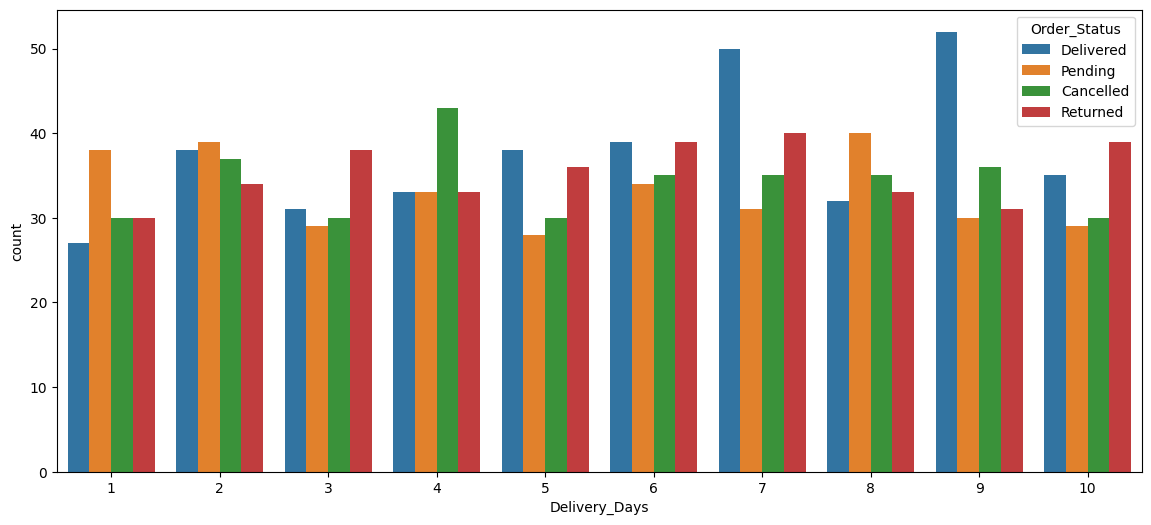

In [ ]:
plt.figure(figsize=(14,6))
sns.countplot(data=df,x=df['Delivery_Days'],hue=df['Order_Status'])

In [ ]:
display(df.groupby('Category')['Quantity'].sum())
print()
display(df.groupby('Category')['Order_ID'].count())

,Quantity
Category,
Automotive,570
Beauty,602
Books,589
Electronics,655
Fashion,553
Home Appliances,571
Sports,590


,Order_ID
Category,
Automotive,198
Beauty,201
Books,206
Electronics,220
Fashion,190
Home Appliances,189
Sports,196


<Axes: xlabel='Category', ylabel='count'>

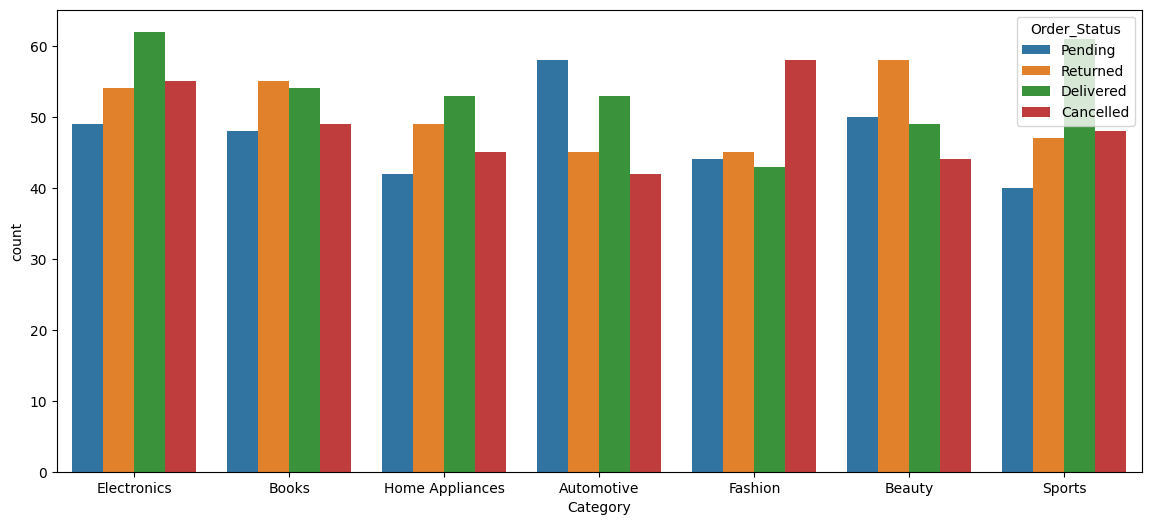

In [ ]:
plt.figure(figsize=(14,6))
sns.countplot(data=df,x=df['Category'],hue=df['Order_Status'])

In [ ]:
df['Product_Name'].nunique()

100

In [ ]:
Most_wanted_products=df.groupby('Product_Name')['Quantity'].sum().sort_values(ascending=False).head(10)
Most_wanted_products

,Quantity
Product_Name,
Sleek Laptop,88
Innovative Smartwatch,75
Budget Smartwatch,69
Innovative Sneakers,67
Sleek Smartwatch,63
Advanced Backpack,63
Budget Tablet,63
Elite Jeans,63
Mega Sneakers,58


In [ ]:
df.to_csv("Cleaned_Daraz_Sales.csv",index=False)